# Experiment 05B — Is our JEPA taking an easy shortcut?

**Question:** Does moving the hidden region and discouraging low-variance features produce a more useful JEPA representation?

Experiment 05 found that our JEPA probe reached `31.6%`, compared with `35.3%` for the pixel model and `31.3%` for raw pixels. A very low prediction loss had not produced the strongest representation. This notebook tests one possible explanation rather than hiding that result.

## Our prediction

A fixed central mask lets the model solve the same spatial puzzle repeatedly. A randomly positioned block should require a broader understanding of the image. A variance regularizer should also make it costly for individual embedding features to become nearly constant.

We compare three versions so we can see where any improvement comes from:

1. **Central mask:** the original JEPA.
2. **Random mask:** the block moves, with no regularizer.
3. **Random mask + variance:** the block moves and low feature variation is penalized.

In [1]:
from pathlib import Path
import sys
project_root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').exists()), None)
if project_root is None:
    raise RuntimeError('Could not find the JEPA Experiments project root')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments')

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset, TensorDataset

from jepa.data import load_cifar10
from jepa.device import best_device
from jepa.evaluation import diversity_metrics
from jepa.masking import centered_block_mask, random_block_mask
from jepa.models import TinyJEPA, masked_embedding_loss

torch.manual_seed(7)
device = best_device()
device

device(type='mps')

## 1. Hold the comparison fixed

All three models see the same 10,000 images, have the same architecture, and train for five epochs. Every mask hides one 4 × 4 block, or 16 of the 64 patches. Only the block position and variance penalty change.

In [3]:
TRAINING_IMAGES = 10_000
TEST_IMAGES = 2_000
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 3e-4
EMBEDDING_DIM = 128
VARIANCE_WEIGHT = 0.10
TARGET_STD = 0.50
PROBE_EPOCHS = 30
PROBE_SEEDS = [11, 22, 33, 44, 55]

train_data = Subset(load_cifar10(train=True), range(TRAINING_IMAGES))
test_data = Subset(load_cifar10(train=False), range(TEST_IMAGES))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_eval_loader = DataLoader(train_data, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=0)
central_mask = centered_block_mask(8, 4, device=device)
print('Training images:', len(train_data))
print('Test images:', len(test_data))
print('Hidden patches per batch:', int(central_mask.sum()))

Training images: 10000
Test images: 2000
Hidden patches per batch: 16


## 2. Define the anti-collapse penalty

For every feature, we measure its standard deviation across images and visible patch positions. If that value falls below `0.5`, the model pays a penalty. Features already above the target pay nothing.

This does not tell a feature what to represent. It only asks the encoder not to make too many features nearly constant.

In [4]:
def variance_penalty(tokens, mask, target_std=TARGET_STD):
    visible = tokens[:, ~mask].flatten(0, 1)
    feature_std = torch.sqrt(visible.var(dim=0, unbiased=False) + 1e-4)
    return F.relu(target_std - feature_std).mean(), feature_std.mean()

example = torch.randn(8, 64, EMBEDDING_DIM, device=device)
penalty, mean_std = variance_penalty(example, central_mask)
print(f'Example feature std: {mean_std.item():.3f}')
print(f'Example penalty:     {penalty.item():.3f}')

Example feature std: 0.997
Example penalty:     0.000


## 3. Create the three JEPAs

The models start from the same random seed, but they are separate networks. Their target encoders follow their own context encoders by exponential moving average.

In [5]:
def make_jepa(seed):
    torch.manual_seed(seed)
    return TinyJEPA(embedding_dim=EMBEDDING_DIM, ema_decay=0.99).to(device)

models = {
    'Central mask': make_jepa(101),
    'Random mask': make_jepa(101),
    'Random + variance': make_jepa(101),
}
optimizers = {
    name: AdamW(
        list(model.context_encoder.parameters()) + list(model.predictor.parameters()),
        lr=LEARNING_RATE,
        weight_decay=0.05,
    )
    for name, model in models.items()
}
history = {name: {'prediction': [], 'variance': [], 'feature_std': []} for name in models}
print('Trainable parameters per model:', sum(p.numel() for p in models['Central mask'].parameters() if p.requires_grad))

/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments/jepa/models.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments/jepa/models.py:142: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Trainable parameters per model: 1229440


## 4. Train under the three conditions

The two random-mask models receive the same randomly located block on every batch. This makes their comparison fair. The total loss for the third model is:

```text
total loss = prediction loss + 0.10 × variance penalty
```

We print prediction loss separately so the regularizer cannot make the original task look artificially better.

In [7]:
mask_generator = torch.Generator().manual_seed(2026)
for epoch in range(EPOCHS):
    totals = {name: {'prediction': 0.0, 'variance': 0.0, 'feature_std': 0.0} for name in models}
    seen = 0
    for images, _ in train_loader:
        images = images.to(device)
        random_mask = random_block_mask(8, 4, device=device, generator=mask_generator)
        batch_masks = {
            'Central mask': central_mask,
            'Random mask': random_mask,
            'Random + variance': random_mask,
        }
        for name, model in models.items():
            model.train()
            mask = batch_masks[name]
            with torch.no_grad():
                target = model.target_encoder(images)
            context_tokens = model.context_encoder(images, mask)
            predicted = model.predictor(context_tokens)
            prediction_loss = masked_embedding_loss(predicted, target, mask)
            variance_loss, feature_std = variance_penalty(context_tokens, mask)
            loss = prediction_loss
            if name == 'Random + variance':
                loss = loss + VARIANCE_WEIGHT * variance_loss
            optimizers[name].zero_grad(set_to_none=True)
            loss.backward()
            optimizers[name].step()
            model.update_target()
            count = images.shape[0]
            totals[name]['prediction'] += prediction_loss.item() * count
            totals[name]['variance'] += variance_loss.item() * count
            totals[name]['feature_std'] += feature_std.item() * count
        seen += images.shape[0]

    print()
    print(f'Epoch {epoch + 1:02d}/{EPOCHS}')
    for name in models:
        for key in totals[name]:
            history[name][key].append(totals[name][key] / seen)
        print(
            f'{name:19s} prediction={history[name]["prediction"][-1]:.6f} | '
            f'penalty={history[name]["variance"][-1]:.4f} | '
            f'feature std={history[name]["feature_std"][-1]:.3f}'
        )


Epoch 01/5
Central mask        prediction=0.000647 | penalty=0.2545 | feature std=0.246
Random mask         prediction=0.000659 | penalty=0.2536 | feature std=0.247
Random + variance   prediction=0.001353 | penalty=0.0014 | feature std=0.805

Epoch 02/5
Central mask        prediction=0.000117 | penalty=0.1663 | feature std=0.342
Random mask         prediction=0.000131 | penalty=0.1561 | feature std=0.358
Random + variance   prediction=0.000934 | penalty=0.0000 | feature std=0.863

Epoch 03/5
Central mask        prediction=0.000108 | penalty=0.1246 | feature std=0.410
Random mask         prediction=0.000147 | penalty=0.1042 | feature std=0.458
Random + variance   prediction=0.001016 | penalty=0.0000 | feature std=0.902

Epoch 04/5
Central mask        prediction=0.000115 | penalty=0.0927 | feature std=0.487
Random mask         prediction=0.000210 | penalty=0.0681 | feature std=0.571
Random + variance   prediction=0.001022 | penalty=0.0000 | feature std=0.905

Epoch 05/5
Central mask    

## 5. Check prediction and variation separately

A revised model is interesting only if it avoids the low-information solution without completely losing the prediction task. These plots show both sides of that trade-off.

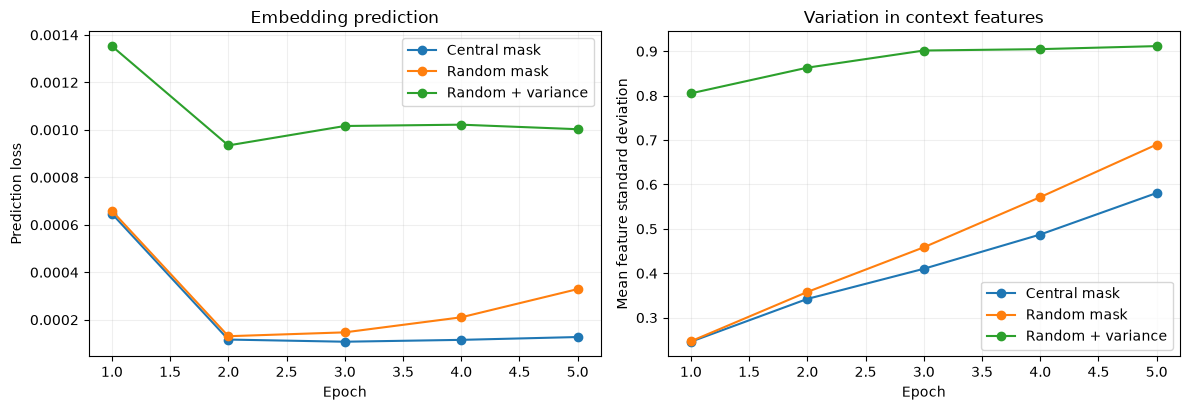

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
epochs = range(1, EPOCHS + 1)
for name in models:
    axes[0].plot(epochs, history[name]['prediction'], marker='o', label=name)
    axes[1].plot(epochs, history[name]['feature_std'], marker='o', label=name)
axes[0].set(title='Embedding prediction', xlabel='Epoch', ylabel='Prediction loss')
axes[1].set(title='Variation in context features', xlabel='Epoch', ylabel='Mean feature standard deviation')
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()

## 6. Measure the frozen representations

We now remove all masks, encode complete images with each EMA target encoder, and mean-pool the 64 patch tokens. Diversity measurements give us a structural check before the downstream probe.

In [9]:
@torch.inference_mode()
def extract_all(loader):
    vectors = {name: [] for name in models}
    tokens = {name: [] for name in models}
    labels = []
    for images, batch_labels in loader:
        images = images.to(device)
        for name, model in models.items():
            model.eval()
            batch_tokens = model.target_encoder(images).cpu()
            tokens[name].append(batch_tokens)
            vectors[name].append(batch_tokens.mean(dim=1))
        labels.append(batch_labels)
    return (
        {name: torch.cat(parts) for name, parts in vectors.items()},
        {name: torch.cat(parts) for name, parts in tokens.items()},
        torch.cat(labels),
    )

train_vectors, train_tokens, train_labels = extract_all(train_eval_loader)
test_vectors, test_tokens, test_labels = extract_all(test_loader)

print('Measurement'.ljust(30), *(name.rjust(20) for name in models))
metrics = {name: diversity_metrics(test_tokens[name]) for name in models}
for key in next(iter(metrics.values())):
    print(key.ljust(30), *(f'{metrics[name][key]:20.4f}' for name in models))

Measurement                            Central mask          Random mask    Random + variance
feature_std                                  0.0433               0.0572               0.0800
within_image_similarity                      0.9978               0.9972               0.9787
across_image_similarity                      0.7106               0.4922               0.1590
effective_rank                              16.0314              13.4284              18.2206


## 7. Repeat the same linear probe

Each representation receives the same standardization, classifier, training budget, and five seeds used in Experiment 05. The encoder weights remain frozen.

In [10]:
def standardize(train, test):
    mean = train.mean(dim=0, keepdim=True)
    std = train.std(dim=0, keepdim=True).clamp_min(1e-6)
    return (train - mean) / std, (test - mean) / std

for name in models:
    train_vectors[name], test_vectors[name] = standardize(train_vectors[name], test_vectors[name])


def run_probe(train_x, test_x, seed):
    torch.manual_seed(seed)
    probe = nn.Linear(train_x.shape[1], 10).to(device)
    optimizer = AdamW(probe.parameters(), lr=3e-3, weight_decay=1e-4)
    loader = DataLoader(
        TensorDataset(train_x, train_labels), batch_size=256, shuffle=True,
        generator=torch.Generator().manual_seed(seed), num_workers=0,
    )
    curve = []
    for _ in range(PROBE_EPOCHS):
        probe.train()
        for vectors, labels in loader:
            loss = F.cross_entropy(probe(vectors.to(device)), labels.to(device))
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        probe.eval()
        with torch.no_grad():
            accuracy = (probe(test_x.to(device)).argmax(1).cpu() == test_labels).float().mean().item()
        curve.append(accuracy)
    return curve

probe_results = {name: [] for name in models}
for name in models:
    for seed in PROBE_SEEDS:
        curve = run_probe(train_vectors[name], test_vectors[name], seed)
        probe_results[name].append(curve)
        print(f'{name:19s} seed={seed:02d} | test={curve[-1]:.1%}')

Central mask        seed=11 | test=30.8%
Central mask        seed=22 | test=29.0%
Central mask        seed=33 | test=29.8%
Central mask        seed=44 | test=29.0%
Central mask        seed=55 | test=29.2%
Random mask         seed=11 | test=28.9%
Random mask         seed=22 | test=28.0%
Random mask         seed=33 | test=28.0%
Random mask         seed=44 | test=27.7%
Random mask         seed=55 | test=27.2%
Random + variance   seed=11 | test=28.2%
Random + variance   seed=22 | test=28.5%
Random + variance   seed=33 | test=28.5%
Random + variance   seed=44 | test=28.4%
Random + variance   seed=55 | test=27.0%


## 8. Decide whether the intervention helped

A useful improvement should raise held-out probe accuracy consistently across seeds. Higher feature variation alone is insufficient: the new variation must carry information the classifier can use.

Model                    Test mean    Test std
Central mask                 29.6%       0.74%
Random mask                  28.0%       0.64%
Random + variance            28.1%       0.65%


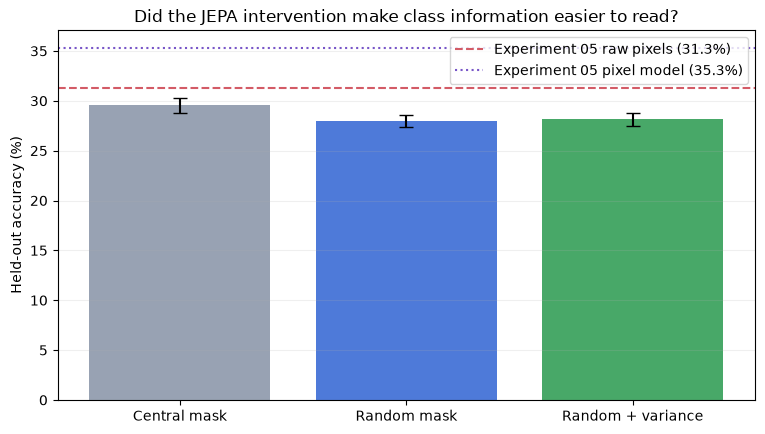

In [11]:
summary = {}
for name, curves in probe_results.items():
    final = torch.tensor([curve[-1] for curve in curves])
    summary[name] = (final.mean().item(), final.std().item())

print('Model'.ljust(21), 'Test mean'.rjust(12), 'Test std'.rjust(11))
for name, (mean, std) in summary.items():
    print(name.ljust(21), f'{mean:.1%}'.rjust(12), f'{std:.2%}'.rjust(11))

names = list(summary)
means = [summary[name][0] * 100 for name in names]
errors = [summary[name][1] * 100 for name in names]
plt.figure(figsize=(9, 4.8))
plt.bar(names, means, yerr=errors, capsize=5, color=['#98A2B3', '#4E7AD9', '#48A868'])
plt.axhline(31.3, color='#D35B66', linestyle='--', label='Experiment 05 raw pixels (31.3%)')
plt.axhline(35.3, color='#7856C8', linestyle=':', label='Experiment 05 pixel model (35.3%)')
plt.ylabel('Held-out accuracy (%)')
plt.title('Did the JEPA intervention make class information easier to read?')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.show()

## What happened in this run

### The interventions changed the representation, but did not improve it

| JEPA condition | Probe accuracy | Standard deviation |
| --- | ---: | ---: |
| Central mask | **29.6%** | 0.74% |
| Random mask | 28.0% | 0.64% |
| Random mask + variance | 28.1% | 0.65% |

Randomly moving the hidden block reduced held-out accuracy by 1.6 percentage points relative to the central-mask control. Adding the variance penalty recovered only 0.1 point. Neither intervention improved linearly accessible CIFAR-10 class information.

All three results were below Experiment 05's raw-pixel reference of `31.3%` and pixel-model result of `35.3%`. Those values came from a separate pretraining run, so the cleanest causal comparison remains the three conditions trained together here.

### Random masking made prediction harder and separated images more

The central-mask model finished with prediction loss `0.000127`. The random-mask model finished at `0.000329`. Moving the block therefore made the predictive task harder, as intended.

It also changed the embedding geometry. Across-image cosine similarity fell from `0.7106` to `0.4922`, and feature standard deviation rose from `0.0433` to `0.0572`. Different images became less alike. However, effective rank fell from `16.03` to `13.43`, and probe accuracy became worse. Removing the fixed spatial shortcut was not sufficient to create more class-relevant structure.

### The variance penalty worked mechanically

During training, the regularized model's mean context-feature standard deviation rose to `0.912`, compared with `0.690` for random masking alone. Its variance penalty reached zero after the first epoch. On complete test images it also had:

- the highest normalized feature standard deviation: `0.0800`;
- the lowest across-image similarity: `0.1590`;
- the highest effective rank: `18.22`;
- the lowest within-image similarity: `0.9787`.

The training-time standard deviation and the later diversity value use different preprocessing and should not be compared numerically. They agree directionally: the regularizer produced much more variation.

Yet probe accuracy remained `28.1%`. The added variation was real, but it was not useful for separating CIFAR-10 classes with a linear boundary.

### A further warning about run-to-run variation

The central control reached `29.6%`, whereas the JEPA in Experiment 05 reached `31.6%`. The architecture and broad recipe were the same, but the self-supervised initialization and training run differed. This two-point swing is larger than the variation among probes trained on one frozen encoder. Repeating only the probe seeds therefore understates the uncertainty in the complete experiment.

## What we learned

Neither of our first explanations was sufficient. The fixed centre was not the main reason for weak semantic performance, and low feature variance alone was not the answer. We can force embeddings to spread out without forcing them to organise around object identity.

The most important result is: **representation diversity is not the same as semantic usefulness.** Our next step should investigate what information the representation preserves before adding more anti-collapse machinery. Invariance tests can reveal whether colour, noise, position, and crop changes dominate the embedding geometry.
